In [ ]:
import pandas as pd
full_table = pd.read_csv('covid_19_clean_complete.csv', header=None)
full_table.columns = ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered']

print("Shape:", full_table.shape)

print("\nData Types:\n", full_table.dtypes)

print("\nSummary Statistics:\n", full_table.describe())

print("\nMissing Values:\n", full_table.isnull().sum())

Shape: (16156, 8)

Data Types:
 Province/State        str
Country/Region        str
Lat               float64
Long              float64
Date                  str
Confirmed           int64
Deaths              int64
Recovered           int64
dtype: object

Summary Statistics:
                 Lat          Long     Confirmed        Deaths     Recovered
count  16043.000000  16043.000000  16156.000000  16156.000000  16156.000000
mean      24.387450     -6.945604    159.780391     37.163964     10.467752
std       24.510267     75.806183   1594.801045    469.121621    188.984080
min      -41.454500   -157.498300      0.000000      0.000000      0.000000
25%        9.748900    -74.521000      0.000000      0.000000      0.000000
50%       31.791700      2.213700      0.000000      0.000000      0.000000
75%       42.733900     36.510000      2.000000      0.000000      0.000000
max       71.706900    178.065000  59138.000000  19958.000000   7931.000000

Missing Values:
 Province/State    9995

In [ ]:
print("\nDuplicate Records:", full_table.duplicated().sum())

print("\nClass Distribution:\n", full_table['Country/Region'].value_counts())


Duplicate Records: 2

Class Distribution:
 Country/Region
US                3416
Canada             732
Australia          549
France             549
United Kingdom     427
                  ... 
Dominica            61
Grenada             61
Mozambique          61
Syria               61
Timor-Leste         61
Name: count, Length: 171, dtype: int64


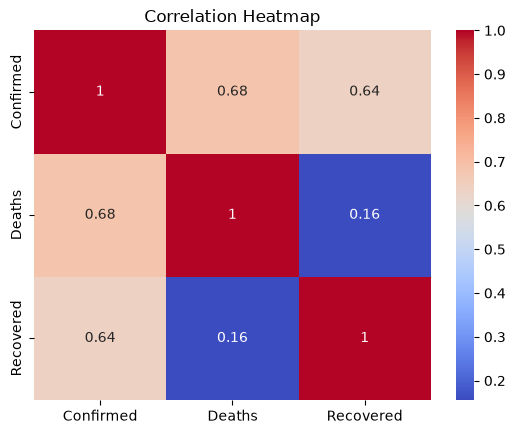

Mean:
 Confirmed    159.780391
Deaths        37.163964
Recovered     10.467752
dtype: float64

Median:
 Confirmed    0.0
Deaths       0.0
Recovered    0.0
dtype: float64

Comparison by Country:
                 Confirmed  Deaths  Recovered
Country/Region                              
Afghanistan           249       1          7
Albania               624      17          4
Algeria               991      77        237
Andorra               423       1         10
Angola                  5       0          0


In [ ]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram
fig = px.histogram(full_table, x="Confirmed", log_y=True, title="Histogram of Confirmed Cases")
fig.show()

# Correlation Heatmap
sns.heatmap(full_table[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Mean & Median
print("Mean:\n", full_table[cols].mean())
print("\nMedian:\n", full_table[cols].median())

# Compare (เปรียบเทียบข้อมูลสรุปรวมรายประเทศ)
print("\nComparison by Country:\n", full_table.groupby('Country/Region')[cols].sum().head())

In [ ]:
full_table = full_table.drop_duplicates()
full_table = full_table.fillna(0)
cols = ['Confirmed', 'Deaths', 'Recovered']
full_table[cols] = full_table[cols].apply(pd.to_numeric, errors='coerce').clip(lower=0)
full_table['Date'] = pd.to_datetime(full_table['Date'])

C:\Users\fluk2\AppData\Local\Temp\ipykernel_10156\3079391963.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_table['Date'] = pd.to_datetime(full_table['Date'])
